## Modeling the agent
1. Feature selection: remove the columns I will not use (for example, the indexing, lat, longitude, and name of the station)
2. Train the models with resampling
3. .....


### Libraries and tools to ues




### Preparation on google colab

!pip install -U ipython

In [ ]:
%load_ext autoreload
%autoreload 2

#Clone the repository
import os
if not os.path.exists("your-project"):
    !git clone https://github.com/ras112git/predictive_modeling_and_mobility_forecasting.git
else:
    print("Repo already cloned.")


%cd predictive_modeling_and_mobility_forecasting

# Install dependencies
!pip install -r requirements.txt

import sys
sys.path.append(os.getcwd())



### Preparation of the venvironment (as on the other notebooks)

In [10]:
%load_ext autoreload
%autoreload 2

import sys, os
from pathlib import Path

# Make src/ importable: add the project root (parent of notebooks/) to sys.path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Run from the project root so relative paths like "data/raw/..." resolve
os.chdir(project_root)
print(f"Working dir: {os.getcwd()}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Working dir: c:\Users\ladak\Documents\GitHub\predictive_modeling_and_mobility_forecasting


### Automatically clean the data

In [11]:
from src.model import *

import pandas as pd

# Start by importing the data
train_path = Path('data/raw/dataset_train.csv')
df_train = pd.read_csv(train_path)

In [12]:
# I will clean it heare, as if I cleaned it and saved it as csv, then the categories will be missed

from src.data_cleaning import clean_data

df_train = clean_data(dataset= df_train, 
                      is_train = True, 
                      categorize_station = True) # If I put false here, it splits the station data in bolean

df_train

,id,datetime,station_number,name,lat,lng,bikes,hour,minute,dayofweek,...,hour_sin,hour_cos,is_holiday,temperature_2m,apparent_temperature,precipitation,snowfall,wind_speed_10m,cloud_cover,relative_humidity_2m
0,2024-09-03 17:30:00_32000,2024-09-03 17:30:00,32000,Julius-Raab-Platz,48.211544,16.382374,25,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
1,2024-09-03 17:30:00_32001,2024-09-03 17:30:00,32001,Hoher Markt,48.210666,16.372983,14,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
2,2024-09-03 17:30:00_32002,2024-09-03 17:30:00,32002,Oper,48.202683,16.369702,9,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
3,2024-09-03 17:30:00_32003,2024-09-03 17:30:00,32003,Volksgarten,48.206516,16.360400,3,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
4,2024-09-03 17:30:00_32004,2024-09-03 17:30:00,32004,Taborstraße U2,48.219522,16.382218,5,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150245,2025-03-13 08:00:00_32275,2025-03-13 08:00:00,32275,eLastenräder - Am langen Felde,48.250224,16.450650,0,8,0,3,...,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88
2150246,2025-03-13 08:00:00_32277,2025-03-13 08:00:00,32277,eLastenräder - Bruno-Marek-Allee 6,48.227914,16.391516,6,8,0,3,...,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88
2150247,2025-03-13 08:00:00_32278,2025-03-13 08:00:00,32278,eLastenräder - Am Tabor 23,48.224598,16.392090,3,8,0,3,...,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88
2150248,2025-03-13 08:00:00_32280,2025-03-13 08:00:00,32280,ALF Mobility-Point,48.251355,16.452810,5,8,0,3,...,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88


### Lag feature engineering

Adding per-station lag features: previous bike counts (30 min, 1h, 2h, 24h, 1 week ago),
a 3-hour rolling mean/std, and a station×hour historical mean.
Rows from the first week of each station's history (where lags are NaN) are dropped.

In [13]:
from src.data_cleaning import add_lag_features

rows_before = len(df_train)
df_train = add_lag_features(df_train)
rows_after = len(df_train)

print(f"Rows before lag features: {rows_before:,}")
print(f"Rows after dropping NaN lags: {rows_after:,}  (dropped {rows_before - rows_after:,} rows)")
print(f"\nNew lag columns: {[c for c in df_train.columns if 'lag' in c or 'roll' in c or c == 'station_hour_mean']}")
df_train[['datetime', 'station_number', 'bikes',
          'bikes_lag_1', 'bikes_lag_48', 'bikes_roll3h_mean', 'station_hour_mean']].head()

Rows before lag features: 2,150,250
Rows after dropping NaN lags: 2,071,290  (dropped 78,960 rows)

New lag columns: ['bikes_lag_1', 'bikes_lag_2', 'bikes_lag_4', 'bikes_lag_48', 'bikes_lag_336', 'bikes_roll3h_mean', 'bikes_roll3h_std', 'station_hour_mean']


,datetime,station_number,bikes,bikes_lag_1,bikes_lag_48,bikes_roll3h_mean,station_hour_mean
0,2024-09-10 17:30:00,32000,27,28.0,21.0,29.500000,10.236220
1,2024-09-10 17:30:00,32014,23,24.0,23.0,24.333333,21.144357
2,2024-09-10 17:30:00,32055,4,4.0,3.0,4.000000,10.719160
3,2024-09-10 17:30:00,32210,7,7.0,16.0,6.500000,23.834646
4,2024-09-10 17:30:00,32177,6,6.0,8.0,6.000000,5.209974


### Feature selection

In [14]:
# Split the features

TARGET = "bikes"

x_train, y_train = data_split(df_train,target=TARGET)
#print(X_train)


In [15]:
#Make sure that the data is ordered by datetime
assert x_train['datetime'].is_monotonic_increasing

# Drop identifier columns. Redundant features (minute, is_weekend, hour_sin,
# hour_cos, snowfall) are automatically dropped inside prepare_features().
DROP_COLS = ["id", "datetime", "name"]

x_train = prepare_features(X=x_train, drop_cols=DROP_COLS)
print("Features used:", x_train.columns.tolist())

Features used: ['station_number', 'lat', 'lng', 'hour', 'dayofweek', 'month', 'is_holiday', 'temperature_2m', 'apparent_temperature', 'precipitation', 'wind_speed_10m', 'cloud_cover', 'relative_humidity_2m', 'bikes_lag_1', 'bikes_lag_2', 'bikes_lag_4', 'bikes_lag_48', 'bikes_lag_336', 'bikes_roll3h_mean', 'bikes_roll3h_std', 'station_hour_mean']


In [16]:
featurce_performance = feature_selection_report(x_train,y_train)

print("features:", featurce_performance)
print("train data shape:", x_train.shape)


features: [5.55299025e-01 5.53399568e-01 5.49549688e-01 4.00730996e-03
 3.47512601e-04 1.14186955e-02 1.10128970e-03 9.33941584e-03
 7.75633555e-03 1.45405050e-04 1.83721253e-03 7.78867691e-04
 1.08386528e-03 2.81347164e+00 2.52142491e+00 2.17649089e+00
 8.66754799e-01 3.33829065e-01 2.45604970e+00 6.27257483e-02
 5.00625600e-01]
train data shape: (2071290, 21)


In [17]:
x_train

,station_number,lat,lng,hour,dayofweek,month,is_holiday,temperature_2m,apparent_temperature,precipitation,...,cloud_cover,relative_humidity_2m,bikes_lag_1,bikes_lag_2,bikes_lag_4,bikes_lag_48,bikes_lag_336,bikes_roll3h_mean,bikes_roll3h_std,station_hour_mean
0,32000,48.211544,16.382374,17,1,9,0,19.5,17.7,0.0,...,25,62,28.0,29.0,30.0,21.0,25.0,29.500000,1.378405e+00,10.236220
1,32014,48.188489,16.343992,17,1,9,0,19.5,17.7,0.0,...,25,62,24.0,24.0,24.0,23.0,29.0,24.333333,1.032796e+00,21.144357
2,32055,48.257535,16.449590,17,1,9,0,19.5,17.7,0.0,...,25,62,4.0,4.0,4.0,3.0,15.0,4.000000,3.457904e-07,10.719160
3,32210,48.221804,16.343735,17,1,9,0,19.5,17.7,0.0,...,25,62,7.0,7.0,6.0,16.0,18.0,6.500000,5.477226e-01,23.834646
4,32177,48.262127,16.387658,17,1,9,0,19.5,17.7,0.0,...,25,62,6.0,6.0,6.0,8.0,7.0,6.000000,0.000000e+00,5.209974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2071285,32211,48.231717,16.353124,8,3,3,0,10.1,7.2,0.5,...,100,88,15.0,15.0,15.0,14.0,20.0,15.000000,0.000000e+00,15.913386
2071286,32050,48.229619,16.453570,8,3,3,0,10.1,7.2,0.5,...,100,88,10.0,10.0,10.0,7.0,6.0,10.000000,0.000000e+00,11.406824
2071287,32212,48.192296,16.274813,8,3,3,0,10.1,7.2,0.5,...,100,88,13.0,13.0,13.0,16.0,10.0,13.000000,0.000000e+00,15.640420
2071288,32053,48.224719,16.498557,8,3,3,0,10.1,7.2,0.5,...,100,88,17.0,17.0,17.0,16.0,15.0,17.000000,0.000000e+00,13.797900


### Benchmarking different methods

In [18]:
#I first need to create all the models that I will asses
model_grid = get_model_grid(Feature_df=x_train)

In [19]:
#Then i train them with the default folds
benchmark_results = benchmark_models(X=x_train,y=y_train,models=model_grid,sample_size=200_000)

c:\Users\ladak\Documents\GitHub\predictive_modeling_and_mobility_forecasting\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 2 is smaller than n_iter=8. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\ladak\Documents\GitHub\predictive_modeling_and_mobility_forecasting\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 2 is smaller than n_iter=8. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\ladak\Documents\GitHub\predictive_modeling_and_mobility_forecasting\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 2 is smaller than n_iter=8. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Featureless fold 1/3: RMSE=9.727  MAE=7.650 RMSLE=1.003
  Featureless fold 2/3: RMSE=8.832  MAE=6.975 RMSLE=0.895
  Featureless fold 3/3: RMSE=9.176  MAE=7.253 RMSLE=0.920
  decision_tree fold 1/3: RMSE=0.836  MAE=0.388 RMSLE=0.106
  decision_tree fold 2/3: RMSE=0.566  MAE=0.187 RMSLE=0.074
  decision_tree fold 3/3: RMSE=0.710  MAE=0.247 RMSLE=0.090
  random_forest fold 1/3: RMSE=0.798  MAE=0.327 RMSLE=0.099
  random_forest fold 2/3: RMSE=0.554  MAE=0.209 RMSLE=0.069
  random_forest fold 3/3: RMSE=0.697  MAE=0.268 RMSLE=0.088
  hist_gbm fold 1/3: RMSE=0.794  MAE=0.325 RMSLE=0.102
  hist_gbm fold 2/3: RMSE=0.550  MAE=0.195 RMSLE=0.071
  hist_gbm fold 3/3: RMSE=0.696  MAE=0.245 RMSLE=0.087
  xgboost fold 1/3: RMSE=0.865  MAE=0.383 RMSLE=0.118
  xgboost fold 2/3: RMSE=0.600  MAE=0.245 RMSLE=0.088
  xgboost fold 3/3: RMSE=0.787  MAE=0.293 RMSLE=0.119
  lightgbm fold 1/3: RMSE=0.787  MAE=0.306 RMSLE=0.097
  lightgbm fold 2/3: RMSE=0.548  MAE=0.195 RMSLE=0.069
  lightgbm fold 3/3: RMSE=0.6

In [20]:
print(benchmark_results)

           model  mean_rmse  std_rmse  mean_mae  mean_rmsle  std_rmsle  \
0       lightgbm   0.675066  0.098365  0.248708    0.084301   0.011757   
1       hist_gbm   0.679928  0.100317  0.255312    0.086503   0.012715   
2  random_forest   0.683140  0.100129  0.268299    0.085155   0.012459   
3  decision_tree   0.704192  0.110400  0.274309    0.089912   0.012724   
4        xgboost   0.750693  0.111272  0.306955    0.108242   0.014155   
5    Featureless   9.245010  0.368573  7.292766    0.939291   0.046106   

   mean_poisson_deviance                                      rmse_per_fold  \
0               0.064164  [0.7874205779826944, 0.5478538443963343, 0.689...   
1               0.066197  [0.7941890164736515, 0.5499713440779134, 0.695...   
2               0.063745  [0.7979746419891259, 0.5539688103491676, 0.697...   
3               0.070302  [0.8363765497792772, 0.5661426524741303, 0.710...   
4               0.087687  [0.8648764255212558, 0.599825170993872, 0.7873...   
5      

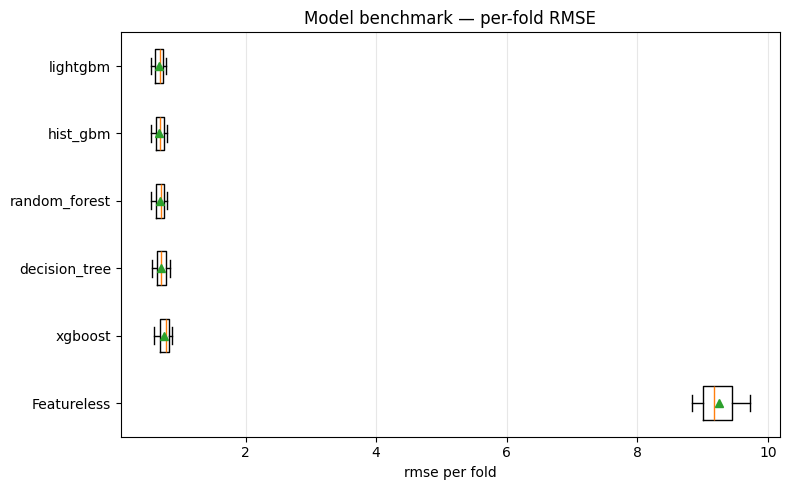

In [21]:
#Finally we print to see the higher performing
from src.model import plot_benchmark

fig, ax = plot_benchmark(benchmark_results)

### Seeing those results, we now select one of the models and train it
This time with more hyperparameters, during a longer period of time, and with a more overall complex resampling strategy.

In [22]:
# Remember to pass a model that handles categorical data, if there will be categorical data in pd version
model_name = "lightgbm"


#model_name = benchmark_results.iloc[0]['model']


model,search = train_final_model(X = x_train,y = y_train,n_iter=40, model_name = model_name,log_target=True) #sample_size to be specified, n_iter

[train_final_model] model=lightgbm  log_target=True  rows=2,071,290  features=21  n_iter=40  cv_splits=3  total_fits=121 (incl. final refit)  scoring=rmsle
[train_final_model] param grid keys: ['regressor__colsample_bytree', 'regressor__learning_rate', 'regressor__max_depth', 'regressor__min_child_samples', 'regressor__n_estimators', 'regressor__num_leaves', 'regressor__reg_alpha', 'regressor__reg_lambda', 'regressor__subsample']

[  1/40] mean_rmsle=0.0847  std=0.0103  folds=['0.097', '0.072', '0.085']  time=85.0s  params={'regressor__subsample': 0.9, 'regressor__reg_lambda': 10.0, 'regressor__reg_alpha': 0.01, 'regressor__num_leaves': 511, 'regressor__n_estimators': 1000, 'regressor__min_child_samples': 5, 'regressor__max_depth': 8, 'regressor__learning_rate': 0.05, 'regressor__colsample_bytree': 0.6}
[  2/40] mean_rmsle=0.0866  std=0.0104  folds=['0.100', '0.074', '0.086']  time=54.8s  params={'regressor__subsample': 0.6, 'regressor__reg_lambda': 10.0, 'regressor__reg_alpha': 0.01, 

In [23]:
print(model)
print(search)

TransformedTargetRegressor(check_inverse=False, func=<ufunc 'log1p'>,
                           inverse_func=<ufunc 'expm1'>,
                           regressor=LGBMRegressor(colsample_bytree=0.8,
                                                   learning_rate=0.05,
                                                   max_depth=12,
                                                   min_child_samples=100,
                                                   n_estimators=200, n_jobs=-2,
                                                   num_leaves=63,
                                                   objective='regression',
                                                   random_state=42,
                                                   reg_alpha=1.0, reg_lambda=0,
                                                   subsample=0.9, verbose=-1))
namespace(best_estimator_=TransformedTargetRegressor(check_inverse=False, func=<ufunc 'log1p'>,
                           inverse_func=<ufunc

In [24]:
evaluate(X = x_train,y = y_train,model=model)

[27.46171756 24.00447755  3.99977827 ... 12.97377249 16.94374885
  1.95767984]
MAE:   0.257
RMSE:  0.712
RMSLE: 0.088


In [25]:
import joblib
# Save the model
joblib.dump(model, f'models/{model_name}v2.joblib')

['models/lightgbmv2.joblib']